
# Lyapunov Exponents: From Maps to Flows, Sampling and Reality

This notebook accompanies the lectures on Lyapunov exponents.  
It collects *all demonstrations* discussed in class:

1. Lyapunov exponent for the **logistic map**
2. **Naive divergence and saturation** on the Lorenz attractor
3. **Renormalized computation** of Lyapunov exponents
4. **Stroboscopic sampling** of a driven system
5. Effects of **blind sampling**
6. **Event / peak sampling** as a physically motivated alternative

The goal is to show not only *how* Lyapunov exponents are computed, but *why* the practical algorithms look the way they do.


## Imports and setup

In [1]:

import numpy as np
from numpy.linalg import norm
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

plt.rcParams['figure.figsize'] = (7,4)



## 1. Logistic map: Lyapunov exponent for a map
We start with the cleanest possible case: a one-dimensional map where the Lyapunov exponent can be computed directly from derivatives.


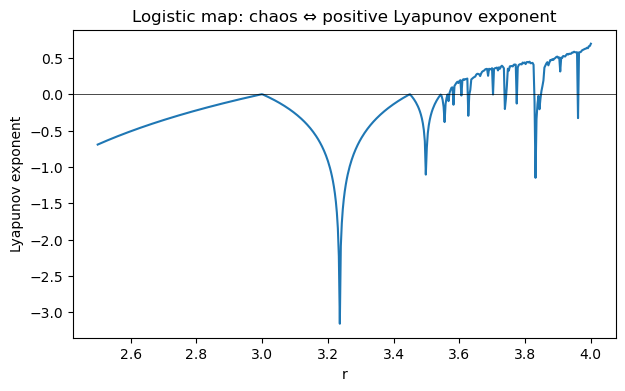

In [2]:

def logistic_map(x, r):
    return r*x*(1-x)

def logistic_lyapunov(r, x0=0.4, N=5000, discard=1000):
    x = x0
    s = 0.0
    for i in range(N):
        x = logistic_map(x, r)
        if i >= discard:
            s += np.log(abs(r*(1-2*x)))
    return s/(N-discard)

rs = np.linspace(2.5, 4.0, 500)
lams = [logistic_lyapunov(r) for r in rs]

plt.plot(rs, lams)
plt.axhline(0, color='k', lw=0.5)
plt.xlabel('r')
plt.ylabel('Lyapunov exponent')
plt.title('Logistic map: chaos ⇔ positive Lyapunov exponent')
plt.show()



## 2. Lorenz system: naive divergence and saturation
We now move to continuous-time systems and show why a naive $t \to\infty$ definition cannot be used directly.


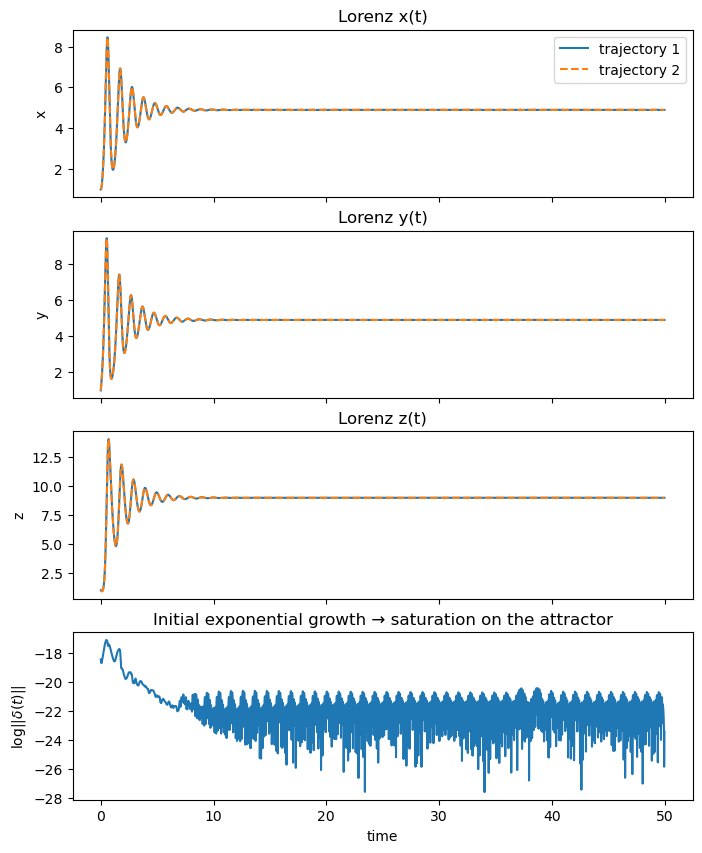

In [51]:

def lorenz(t, X, sigma=10.0, rho=10.0, beta=8/3):
    x, y, z = X
    return [
        sigma*(y-x),
        x*(rho-z)-y,
        x*y-beta*z
    ]

x0 = np.array([1.,1.,1.])
delta0 = 1e-8*np.array([1.,0.,0.])

dt = 0.01
t_max=50
t_eval = np.arange(0, t_max, dt)

sol1 = solve_ivp(lorenz, [0,t_max], x0, t_eval=t_eval)
sol2 = solve_ivp(lorenz, [0,t_max], x0+delta0, t_eval=t_eval)

dist = np.linalg.norm(sol2.y.T - sol1.y.T, axis=1)
fig, axes = plt.subplots(4, 1, figsize=(8, 10), sharex=True)

labels = ['x', 'y', 'z']
for i, ax in enumerate(axes[:3]):
    ax.plot(t_eval, sol1.y[i], label='trajectory 1')
    ax.plot(t_eval, sol2.y[i], '--', label='trajectory 2')
    ax.set_ylabel(labels[i])
    ax.set_title(f'Lorenz {labels[i]}(t)')
    if i == 0:
        ax.legend()

plt.sca(axes[3])
plt.plot(t_eval, np.log(dist))
plt.xlabel('time')
plt.ylabel(r'$\log||\delta(t)||$')
plt.title('Initial exponential growth → saturation on the attractor')
plt.show()



**Key observation:** exponential growth only occurs while trajectories are close.  
Once the separation reaches the attractor size, growth saturates and carries no information about instability.


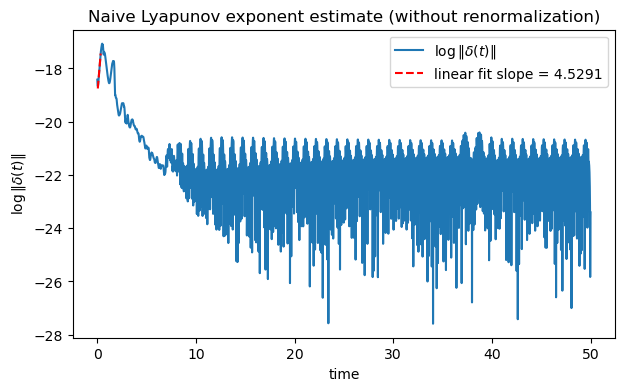

Naive Lyapunov exponent estimate: 4.5291


In [52]:
# Naive Lyapunov estimate (no renormalization):
# fit a line to log(||delta(t)||) over an early-time window

log_dist = np.log(dist)

# choose an early window before any possible saturation effects
fit_start, fit_end = 5, 35
coef = np.polyfit(t_eval[fit_start:fit_end], log_dist[fit_start:fit_end], 1)
lam_no_renorm = coef[0]

plt.figure()
plt.plot(t_eval, log_dist, label=r'$\log\|\delta(t)\|$')
plt.plot(
    t_eval[fit_start:fit_end],
    np.polyval(coef, t_eval[fit_start:fit_end]),
    'r--',
    label=f'linear fit slope = {lam_no_renorm:.4f}'
)
plt.xlabel('time')
plt.ylabel(r'$\log\|\delta(t)\|$')
plt.title('Naive Lyapunov exponent estimate (without renormalization)')
plt.legend()
plt.show()

print(f'Naive Lyapunov exponent estimate: {lam_no_renorm:.4f}')


## 3. Renormalized Lyapunov exponent (what is really done)
To extract the exponential growth *before saturation*, we repeatedly renormalize perturbations.


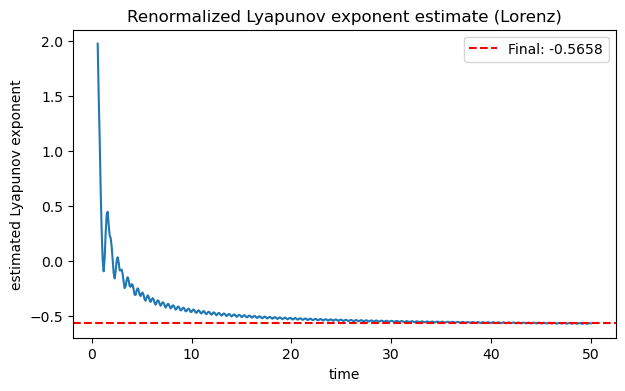

Estimated largest Lyapunov exponent: -0.5658


In [53]:
def lyapunov_lorenz_renorm(x0, delta0, T=30, renorm_time=0.1):
    x = x0.copy()
    d = delta0.copy()
    logs = []
    t = 0.0

    while t < T:
        sol_x = solve_ivp(lorenz, [0, renorm_time], x, dense_output=False)
        sol_d = solve_ivp(lorenz, [0, renorm_time], x + d, dense_output=False)

        x_new = sol_x.y[:, -1]
        d_new = sol_d.y[:, -1] - x_new

        growth = norm(d_new) / norm(d)
        logs.append(np.log(growth) / renorm_time)

        # renormalize: keep direction, reset magnitude
        d = d_new / norm(d_new) * norm(delta0)
        x = x_new
        t += renorm_time

    times = np.arange(1, len(logs) + 1) * renorm_time
    cumulative = np.cumsum(logs) / np.arange(1, len(logs) + 1)
    return times, cumulative

times, lam_renorm = lyapunov_lorenz_renorm(x0, delta0, T=t_max, renorm_time=0.1)

plt.figure()
plt.plot(times[5:], lam_renorm[5:])
plt.axhline(lam_renorm[-1], color='r', linestyle='--', label=f'Final: {lam_renorm[-1]:.4f}')
plt.xlabel('time')
plt.ylabel('estimated Lyapunov exponent')
plt.title('Renormalized Lyapunov exponent estimate (Lorenz)')
plt.legend()
plt.show()

print(f'Estimated largest Lyapunov exponent: {lam_renorm[-1]:.4f}')


## 4. Driven pendulum and stroboscopic sampling
Periodic forcing allows an exact reduction to a discrete-time stroboscopic map.


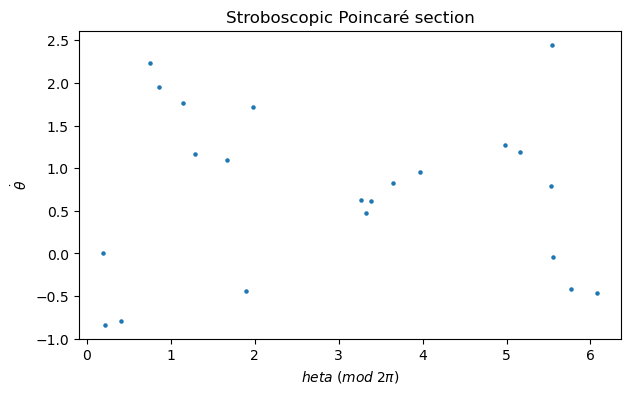

In [17]:

def pendulum(t, X, gamma=0.2, A=1.2, omega=2/3):
    theta, w = X
    return [w, -gamma*w - np.sin(theta) + A*np.cos(omega*t)]

omega=2/3
T = 2*np.pi/omega

t_eval = np.linspace(0, 200, 40000)
sol = solve_ivp(pendulum, [0,200], [0.2,0.0], t_eval=t_eval)

# stroboscopic sampling
idx = np.arange(0, len(t_eval), int(T/(t_eval[1]-t_eval[0])))

plt.scatter(sol.y[0, idx]%(2*np.pi), sol.y[1, idx], s=5)
plt.xlabel(r'$	heta \; (mod\;2\pi)$')
plt.ylabel(r'$\dot	\theta$')
plt.title('Stroboscopic Poincaré section')
plt.show()


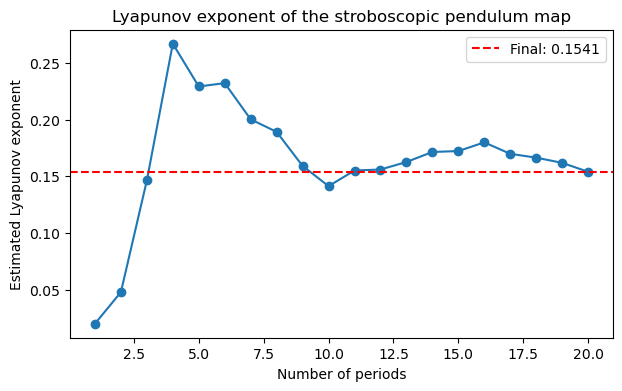

Estimated Lyapunov exponent (stroboscopic): 0.1541


In [35]:
# Lyapunov exponent of the stroboscopic map via renormalization
def pendulum_lyapunov_stroboscopic(x0, T_period, n_periods=20, epsilon=1e-8):
    """
    Estimate the largest Lyapunov exponent of the stroboscopic map
    by evolving nearby trajectories over each period and renormalizing.
    """
    x = np.array(x0, dtype=float)
    d = np.array([epsilon, 0.0])
    logs = []
    t_start = 0.0

    for _ in range(n_periods):
        sol_x = solve_ivp(pendulum, [t_start, t_start + T_period], x, max_step=0.01)
        sol_d = solve_ivp(pendulum, [t_start, t_start + T_period], x + d, max_step=0.01)

        x_new = sol_x.y[:, -1]
        d_new = sol_d.y[:, -1] - x_new

        growth = norm(d_new) / norm(d)
        logs.append(np.log(growth))

        d = d_new / norm(d_new) * epsilon
        x = x_new
        t_start += T_period

    cumulative = np.cumsum(logs) / (np.arange(1, len(logs) + 1) * T_period)
    return cumulative

n_periods = 20
lam_strob = pendulum_lyapunov_stroboscopic([0.2, 0.0], T, n_periods=n_periods)

plt.figure()
plt.plot(np.arange(1, n_periods + 1), lam_strob, marker='o')
plt.axhline(lam_strob[-1], color='r', linestyle='--', label=f'Final: {lam_strob[-1]:.4f}')
plt.xlabel('Number of periods')
plt.ylabel('Estimated Lyapunov exponent')
plt.title('Lyapunov exponent of the stroboscopic pendulum map')
plt.legend()
plt.show()

print(f'Estimated Lyapunov exponent (stroboscopic): {lam_strob[-1]:.4f}')

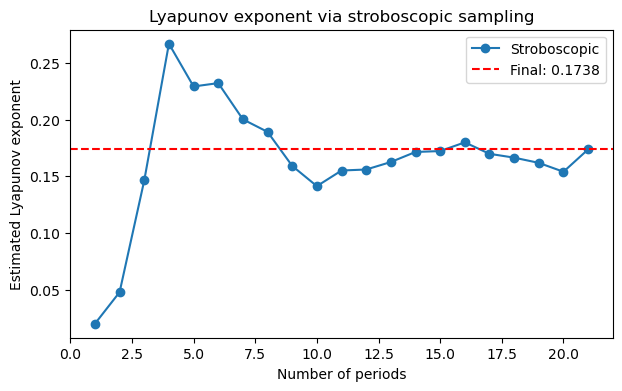

Estimated Lyapunov exponent (stroboscopic map): 0.1738
Comparison - previous stroboscopic: 0.1541


In [54]:
# Lyapunov exponent via stroboscopic sampling (renormalized over each period)
def pendulum_lyapunov_stroboscopic_map(x0_state, T_period, t_start, n_periods=50, epsilon=1e-8):
    """
    Estimate the largest Lyapunov exponent using stroboscopic (fixed period) sampling.
    Each integration window is exactly one forcing period T.
    """
    x = np.array(x0_state, dtype=float)
    d = np.array([epsilon, 0.0])
    logs = []
    t = t_start

    for _ in range(n_periods):
        sol_x = solve_ivp(pendulum, [t, t + T_period], x, max_step=0.01)
        sol_d = solve_ivp(pendulum, [t, t + T_period], x + d, max_step=0.01)

        x_new = sol_x.y[:, -1]
        d_new = sol_d.y[:, -1] - x_new

        growth = norm(d_new) / norm(d)
        logs.append(np.log(growth) / T_period)

        d = d_new / norm(d_new) * epsilon
        x = x_new
        t += T_period

    cumulative = np.cumsum(logs) / np.arange(1, len(logs) + 1)
    return cumulative

# Start from the first stroboscopic sample point
x0_strob = sol.y[:, idx[0]]
n_periods_strob = len(idx) - 1
lam_strob_map = pendulum_lyapunov_stroboscopic_map(x0_strob, T, t_start=t_eval[idx[0]], n_periods=n_periods_strob)

plt.figure()
plt.plot(np.arange(1, len(lam_strob_map) + 1), lam_strob_map, marker='o', label='Stroboscopic')
plt.axhline(lam_strob_map[-1], color='r', linestyle='--', label=f'Final: {lam_strob_map[-1]:.4f}')
plt.xlabel('Number of periods')
plt.ylabel('Estimated Lyapunov exponent')
plt.title('Lyapunov exponent via stroboscopic sampling')
plt.legend()
plt.show()

print(f'Estimated Lyapunov exponent (stroboscopic map): {lam_strob_map[-1]:.4f}')
print(f'Comparison - previous stroboscopic: {lam_strob[-1]:.4f}')



## 5. Blind fixed-time sampling
Sampling at an unrelated interval blurs the geometric structure.


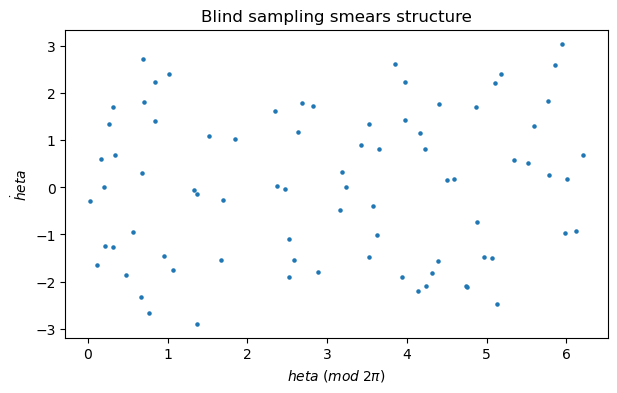

In [6]:

idx_blind = np.arange(0, len(t_eval), 500)

plt.scatter(sol.y[0, idx_blind]%(2*np.pi), sol.y[1, idx_blind], s=5)
plt.xlabel(r'$	heta \; (mod\;2\pi)$')
plt.ylabel(r'$\dot	heta$')
plt.title('Blind sampling smears structure')
plt.show()


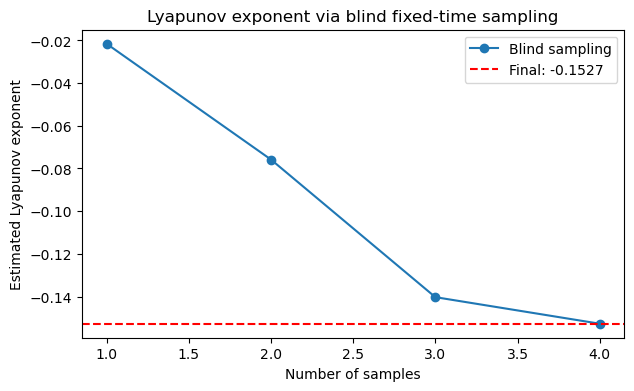

Estimated Lyapunov exponent (blind sampling): -0.1527
Comparison - stroboscopic: 0.1738


In [40]:
# Lyapunov exponent via blind fixed-time sampling
def pendulum_lyapunov_blind_sampling(x0_state, sample_interval, t_start, t_end, epsilon=1e-8):
    """
    Estimate the largest Lyapunov exponent using blind (unrelated) fixed-time sampling.
    """
    x = np.array(x0_state, dtype=float)
    d = np.array([epsilon, 0.0])
    logs = []
    t = t_start

    while t < t_end:
        sol_x = solve_ivp(pendulum, [t, t + sample_interval], x, max_step=0.01)
        sol_d = solve_ivp(pendulum, [t, t + sample_interval], x + d, max_step=0.01)

        x_new = sol_x.y[:, -1]
        d_new = sol_d.y[:, -1] - x_new

        growth = norm(d_new) / norm(d)
        logs.append(np.log(growth) / sample_interval)

        d = d_new / norm(d_new) * epsilon
        x = x_new
        t += sample_interval

    cumulative = np.cumsum(logs) / np.arange(1, len(logs) + 1)
    return cumulative

# Use blind sampling interval (unrelated to forcing period T)
blind_interval = 0.5
lam_blind = pendulum_lyapunov_blind_sampling([0.2, 0.0], blind_interval, t_start=0, t_end=t_eval[-1])

plt.figure()
plt.plot(np.arange(1, len(lam_blind) + 1), lam_blind, marker='o', label='Blind sampling')
plt.axhline(lam_blind[-1], color='r', linestyle='--', label=f'Final: {lam_blind[-1]:.4f}')
plt.xlabel('Number of samples')
plt.ylabel('Estimated Lyapunov exponent')
plt.title('Lyapunov exponent via blind fixed-time sampling')
plt.legend()
plt.show()

print(f'Estimated Lyapunov exponent (blind sampling): {lam_blind[-1]:.4f}')
print(f'Comparison - stroboscopic: {lam_strob_map[-1]:.4f}')


## 6. Sampling local maxima (event-based Poincaré section)
Instead of sampling at fixed times, we sample *events* defined by the dynamics itself.


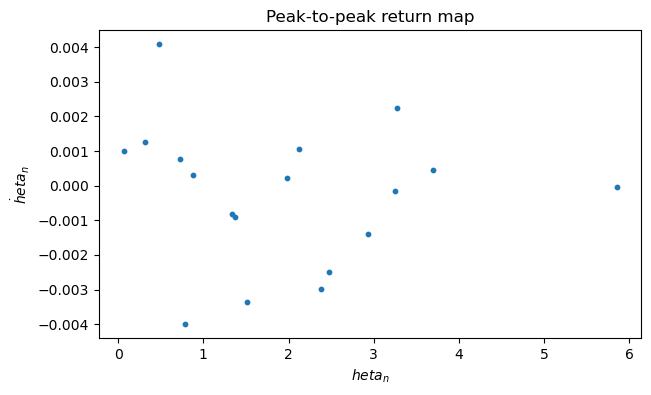

In [7]:

theta = sol.y[0]

peaks = np.where((theta[1:-1] > theta[:-2]) & (theta[1:-1] > theta[2:]))[0]+1

plt.scatter(theta[peaks]%(2*np.pi), sol.y[1, peaks], s=10)
plt.xlabel(r'$	heta_{n}$')
plt.ylabel(r'$\dot	heta_{n}$')
plt.title('Peak-to-peak return map')
plt.show()


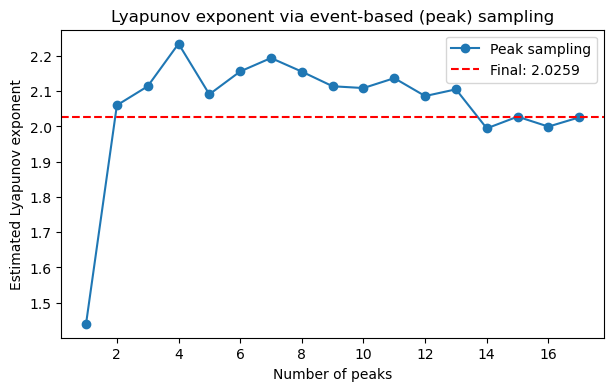

Estimated Lyapunov exponent (peak sampling): 2.0259
Comparison - stroboscopic: 0.1738
Comparison - blind sampling: -0.1527


In [41]:
# Lyapunov exponent via event-based (peak) sampling
def pendulum_lyapunov_peak_sampling(peaks_idx, sol, epsilon=1e-8):
    """
    Estimate the largest Lyapunov exponent using event-based sampling (peaks).
    """
    logs = []
    
    for i in range(len(peaks_idx) - 1):
        idx_current = peaks_idx[i]
        idx_next = peaks_idx[i + 1]
        
        x_current = sol.y[:, idx_current]
        x_next = sol.y[:, idx_next]
        
        delta_obs = x_next - x_current
        growth = norm(delta_obs) / epsilon
        
        # Time between successive peaks
        t_current = sol.t[idx_current]
        t_next = sol.t[idx_next]
        dt = t_next - t_current
        
        logs.append(np.log(growth) / dt)
    
    cumulative = np.cumsum(logs) / np.arange(1, len(logs) + 1)
    return cumulative

lam_peaks = pendulum_lyapunov_peak_sampling(peaks, sol)

plt.figure()
plt.plot(np.arange(1, len(lam_peaks) + 1), lam_peaks, marker='o', label='Peak sampling')
plt.axhline(lam_peaks[-1], color='r', linestyle='--', label=f'Final: {lam_peaks[-1]:.4f}')
plt.xlabel('Number of peaks')
plt.ylabel('Estimated Lyapunov exponent')
plt.title('Lyapunov exponent via event-based (peak) sampling')
plt.legend()
plt.show()

print(f'Estimated Lyapunov exponent (peak sampling): {lam_peaks[-1]:.4f}')
print(f'Comparison - stroboscopic: {lam_strob_map[-1]:.4f}')
print(f'Comparison - blind sampling: {lam_blind[-1]:.4f}')


## Final message
- Lyapunov exponents describe **local exponential instability**.
- Saturation on attractors is unavoidable and *not a contradiction*.
- Practical computation relies on **short-time growth + averaging**.
- Sampling choices (stroboscopic, blind, event-based) determine what structure we see.

**Chaos is not measured by letting trajectories run forever.**
